# Partie 2 — Détection d'Images IA vs Réelles (CNN)

**Projet :** Fake News Detection & AI Image Detection System
**Framework :** TensorFlow / Keras
**Architecture :** CNN personnalisé + Transfer Learning (MobileNetV2)

---

## Plan de cette partie

| Étape | Description |
|-------|-------------|
| 1 | Installation & imports |
| 2 | Dataset : CIFAKE (images IA vs réelles) |
| 3 | Prétraitement et augmentation des données |
| 4 | Architecture CNN (construit from scratch) |
| 5 | Entraînement avec callbacks |
| 6 | Évaluation complète + courbes |
| 7 | Transfer Learning avec MobileNetV2 (bonus) |
| 8 | Sauvegarde du modèle |
| 9 | Démo d'inférence sur une image |

---

## Dataset requis : CIFAKE

Télécharge le dataset depuis Kaggle :
https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images

**Structure après téléchargement :**
```
data/
  train/
    REAL/      (32x32 images réelles — CIFAR-10)
    FAKE/      (32x32 images IA — Stable Diffusion)
  test/
    REAL/
    FAKE/
```

**Taille :** ~60 000 images (50k train + 10k test), 32x32 px, équilibré 50/50.


---
## Étape 1 — Installation & Imports

In [4]:
# ── Imports système ──────────────────────────────────────────────────────────
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
%matplotlib inline

# ── TensorFlow / Keras ────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2

# ── Evaluation ────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc
)

print(f'TensorFlow version : {tf.__version__}')
print(f'GPU disponible     : {len(tf.config.list_physical_devices("GPU")) > 0}')
print(f'Devices            : {[d.device_type for d in tf.config.list_physical_devices()]}')

TensorFlow version : 2.13.0
GPU disponible     : False
Devices            : ['CPU']


---
## Étape 2 — Chargement et exploration du dataset CIFAKE

### Pourquoi CIFAKE ?
- **60 000 images** équilibrées : 50% REAL (CIFAR-10) / 50% FAKE (Stable Diffusion v1.4)
- **Format simple** : dossiers organisés par classe, parfait pour `ImageDataGenerator`
- **Benchmark reconnu** : utilisé dans des publications académiques sur la détection d'images IA


In [5]:
# ── Configuration des chemins ─────────────────────────────────────────────────
TRAIN_DIR = 'data/train'
TEST_DIR  = 'data/test'
IMG_SIZE  = (64, 64)      # on upscale 32x32 → 64x64 pour plus de détail
BATCH_SIZE = 32
EPOCHS     = 20
SEED       = 42

# ── Vérification de la structure du dataset ───────────────────────────────────
for split, path in [('TRAIN', TRAIN_DIR), ('TEST', TEST_DIR)]:
    if os.path.exists(path):
        for cls in ['REAL', 'FAKE']:
            cls_path = os.path.join(path, cls)
            count = len(os.listdir(cls_path)) if os.path.exists(cls_path) else 0
            print(f'  {split}/{cls} : {count:,} images')
    else:
        print(f'  ATTENTION : dossier {path} introuvable')
        print(f'  --> Place le dataset CIFAKE dans data/train et data/test')

  TRAIN/REAL : 50,000 images
  TRAIN/FAKE : 50,000 images
  TEST/REAL : 10,000 images
  TEST/FAKE : 10,000 images


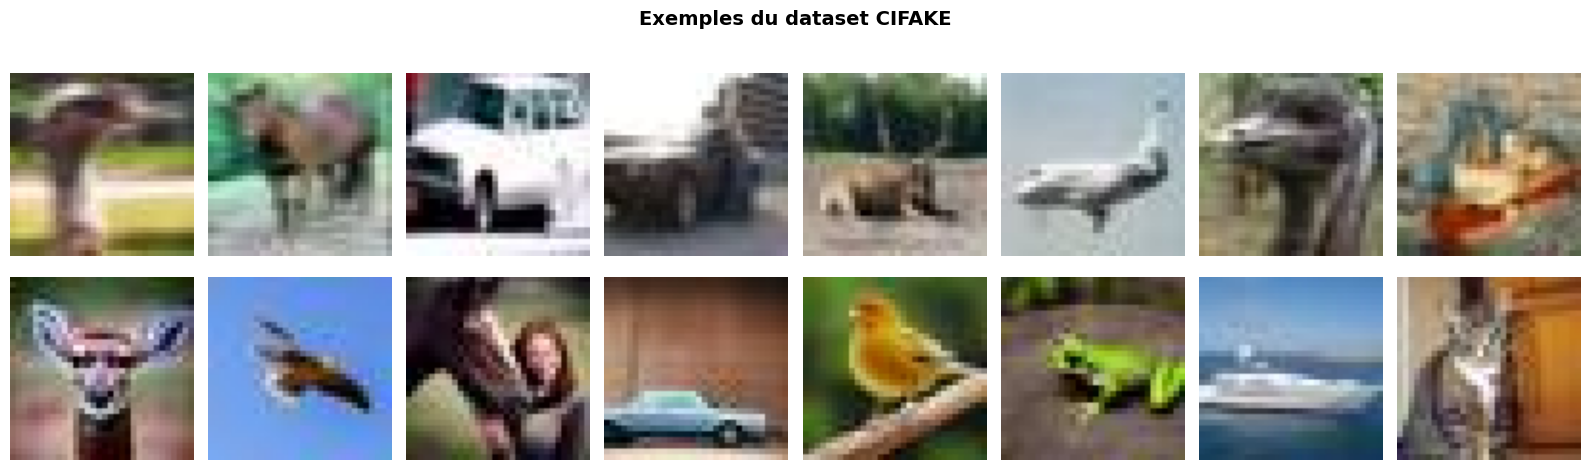

Sauvegarde : outputs/sample_images.png


In [6]:
# ── Afficher des exemples d'images ───────────────────────────────────────────
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Exemples du dataset CIFAKE', fontsize=14, fontweight='bold')

for row, cls in enumerate(['REAL', 'FAKE']):
    cls_path = os.path.join(TRAIN_DIR, cls)
    images   = os.listdir(cls_path)[:8]
    for col, img_name in enumerate(images):
        img = load_img(os.path.join(cls_path, img_name), target_size=IMG_SIZE)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            label_color = '#00B894' if cls == 'REAL' else '#E17055'
            axes[row, col].set_ylabel(cls, fontsize=12,
                                       color=label_color, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegarde : outputs/sample_images.png')

---
## Étape 3 — Prétraitement et Augmentation des données

### Pourquoi l'augmentation ?
Sans augmentation, le modèle mémorise les images d'entraînement (overfitting).
L'augmentation crée artificiellement plus de variété :

| Transformation | Effet |
|----------------|-------|
| Rotation ±20° | Invariance à l'orientation |
| Zoom 20% | Invariance à l'échelle |
| Flip horizontal | Double la diversité |
| Décalage 20% | Invariance à la position |
| Changement de luminosité | Robustesse aux conditions d'éclairage |

**Important :** l'augmentation s'applique **uniquement au train**, jamais au test.


In [7]:
# ── Générateur d'entraînement (avec augmentation) ────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,              # normaliser pixels [0,255] → [0,1]
    rotation_range=20,           # rotation aléatoire ±20 degrés
    width_shift_range=0.2,       # décalage horizontal ±20%
    height_shift_range=0.2,      # décalage vertical ±20%
    shear_range=0.15,            # cisaillement
    zoom_range=0.2,              # zoom aléatoire ±20%
    horizontal_flip=True,        # miroir horizontal
    brightness_range=[0.8, 1.2], # variation de luminosité
    fill_mode='nearest'          # remplir les pixels manquants
)

# ── Générateur de test (SANS augmentation — juste normalisation) ───────────────
test_datagen = ImageDataGenerator(
    rescale=1./255               # même normalisation, mais aucune transformation
)

# ── Chargement des données depuis les dossiers ────────────────────────────────
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',         # 0 = FAKE, 1 = REAL
    seed=SEED,
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=SEED,
    shuffle=False                # NE PAS mélanger pour l'évaluation
)

print(f'\nClasses : {train_generator.class_indices}')
print(f'Batches train : {len(train_generator)}')
print(f'Batches test  : {len(test_generator)}')

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.

Classes : {'FAKE': 0, 'REAL': 1}
Batches train : 3125
Batches test  : 625


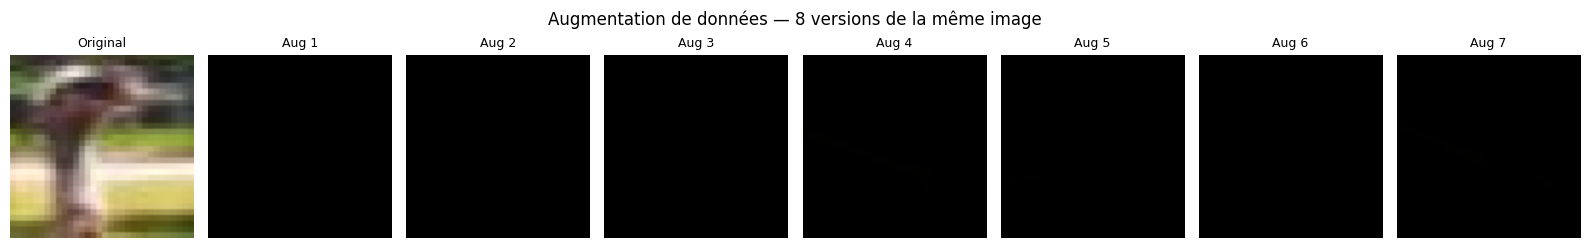

In [9]:
# ── Visualiser des images augmentées ─────────────────────────────────────────
# Prendre une seule image réelle et montrer 8 versions augmentées
sample_img_path = os.path.join(TRAIN_DIR, 'REAL', os.listdir(os.path.join(TRAIN_DIR, 'REAL'))[0])
sample_img      = load_img(sample_img_path, target_size=IMG_SIZE)
sample_arr      = img_to_array(sample_img)
sample_arr      = sample_arr.reshape((1,) + sample_arr.shape)

aug_gen = train_datagen.flow(sample_arr, batch_size=1)

fig, axes = plt.subplots(1, 8, figsize=(16, 2.5))
fig.suptitle('Augmentation de données — 8 versions de la même image', fontsize=12)
axes[0].imshow(sample_img)
axes[0].set_title('Original', fontsize=9)
axes[0].axis('off')
for i in range(1, 8):
    batch = next(aug_gen)
    axes[i].imshow(batch[0].astype('uint8'))
    axes[i].set_title(f'Aug {i}', fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

---
## Étape 4 — Architecture CNN (from scratch)

### Comment fonctionne un CNN ?

```
Image (64x64x3)
  → Conv2D + ReLU      : détecte les bords et textures simples
  → MaxPooling2D       : réduit la taille, garde les features importantes
  → Conv2D + ReLU      : détecte des patterns plus complexes
  → MaxPooling2D
  → Conv2D + ReLU      : formes, structures globales
  → GlobalAveragePooling2D  : résumé compact
  → Dense + Dropout    : combinaison des features
  → Dense(1, sigmoid)  : probabilité [0,1] → FAKE ou REAL
```

### Choix d'architecture :
- **3 blocs Conv** : adapté pour des images 64x64
- **BatchNormalization** : stabilise et accélère l'entraînement
- **Dropout(0.5)** : réduit l'overfitting (désactive 50% des neurones aléatoirement)
- **GlobalAveragePooling** : plus robuste que Flatten pour la classification


In [10]:
def build_cnn_model(input_shape=(64, 64, 3)):
    """
    Construit un CNN de classification binaire (FAKE vs REAL).
    
    Architecture :
      3 blocs convolutifs (Conv → BN → ReLU → MaxPool)
      1 tête de classification (GAP → Dense → Dropout → Output)
    """
    model = models.Sequential([
        
        # ── Bloc 1 : détection des features bas niveau ────────────────────────
        # (bords, contours, textures simples)
        layers.Conv2D(32, (3,3), padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),           # 64x64 → 32x32
        layers.Dropout(0.25),
        
        # ── Bloc 2 : features de niveau intermédiaire ─────────────────────────
        # (formes géométriques, patterns répétitifs)
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),           # 32x32 → 16x16
        layers.Dropout(0.25),
        
        # ── Bloc 3 : features haut niveau ────────────────────────────────────
        # (structures sémantiques, artefacts IA)
        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),           # 16x16 → 8x8
        layers.Dropout(0.25),
        
        # ── Tête de classification ────────────────────────────────────────────
        layers.GlobalAveragePooling2D(),     # 8x8x128 → 128 (résumé compact)
        layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),                 # dropout fort avant la sortie
        layers.Dense(1, activation='sigmoid')  # sortie : probabilité [0,1]
    ])
    
    return model


# ── Instancier et compiler le modèle ─────────────────────────────────────────
model_cnn = build_cnn_model(input_shape=(*IMG_SIZE, 3))

model_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',    # adapté à la classification binaire
    metrics=['accuracy',
             keras.metrics.AUC(name='auc'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)

# ── Résumé de l'architecture ─────────────────────────────────────────────────
model_cnn.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 64, 64, 32)        896       
                                                                 
 batch_normalization (Batch  (None, 64, 64, 32)        128       
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 64, 64, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 32)        9248      
                                                                 
 batch_normalization_1 (Bat  (None, 64, 64, 32)        128       
 chNormalization)                                                
                                                                 
 activation_1 (Activation)   (None, 64, 64, 32)        0

In [11]:
# ── Visualiser l'architecture ─────────────────────────────────────────────────
# Compte les paramètres par couche
total_params     = model_cnn.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model_cnn.trainable_weights])

print(f'\nTotal parametres     : {total_params:,}')
print(f'Parametres entrainables : {trainable_params:,}')
print(f'Taille approximative (float32) : {total_params * 4 / 1024 / 1024:.1f} MB')


Total parametres     : 323,105
Parametres entrainables : 321,697
Taille approximative (float32) : 1.2 MB


---
## Étape 5 — Entraînement avec Callbacks

### Callbacks utilisés :
- **ModelCheckpoint** : sauvegarde automatiquement le meilleur modèle (val_accuracy)
- **EarlyStopping** : arrête si le val_loss ne s'améliore plus (évite l'overfitting)
- **ReduceLROnPlateau** : réduit le learning rate si le modèle stagne
- **TensorBoard** : logs pour visualisation (optionnel)


In [16]:
os.makedirs('models', exist_ok=True)
os.makedirs('outputs', exist_ok=True)
os.makedirs('logs',    exist_ok=True)

# ── Définition des callbacks ──────────────────────────────────────────────────
cbs = [
    # Sauvegarde le meilleur modèle (selon val_accuracy)
    callbacks.ModelCheckpoint(
    filepath='models/cnn_best.h5',   # 🔥 change ici
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
),
    
    # Arrêt anticipé si val_loss ne s'améliore plus pendant 5 époques
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Réduction du learning rate si val_loss stagne (plateau)
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,          # divise le LR par 2
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    
    # Logs TensorBoard (lance avec : tensorboard --logdir logs/)
    callbacks.TensorBoard(log_dir='logs/', histogram_freq=1)
]

# ── Entraînement ──────────────────────────────────────────────────────────────
print('Debut de l entrainement...')
print(f'Epochs max    : {EPOCHS}')
print(f'Batch size    : {BATCH_SIZE}')
print(f'Learning rate : 0.001 (adaptatif)')
print()

history_cnn = model_cnn.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator,
    callbacks=cbs,
    verbose=1
)

print('\nEntrainement termine !')

Debut de l entrainement...
Epochs max    : 20
Batch size    : 32
Learning rate : 0.001 (adaptatif)

Epoch 1/20
3125/3125 [==============================] - ETA: 0s - loss: 0.2729 - accuracy: 0.8924 - auc: 0.9572 - precision: 0.8931 - recall: 0.8915
Epoch 1: val_accuracy improved from -inf to 0.91555, saving model to models/cnn_best.h5
3125/3125 [==============================] - 2760s 883ms/step - loss: 0.2729 - accuracy: 0.8924 - auc: 0.9572 - precision: 0.8931 - recall: 0.8915 - val_loss: 0.2294 - val_accuracy: 0.9155 - val_auc: 0.9749 - val_precision: 0.9554 - val_recall: 0.8718 - lr: 0.0010
Epoch 2/20
3125/3125 [==============================] - ETA: 0s - loss: 0.2503 - accuracy: 0.9018 - auc: 0.9631 - precision: 0.9014 - recall: 0.9022
Epoch 2: val_accuracy did not improve from 0.91555
3125/3125 [==============================] - 2831s 906ms/step - loss: 0.2503 - accuracy: 0.9018 - auc: 0.9631 - precision: 0.9014 - recall: 0.9022 - val_loss: 0.2797 - val_accuracy: 0.8856 - val_auc

---
## Étape 6 — Évaluation complète

On analyse :
1. **Courbes d'apprentissage** (loss et accuracy sur train vs val)
2. **Métriques finales** (accuracy, precision, recall, F1, AUC)
3. **Matrice de confusion**
4. **Courbe ROC**


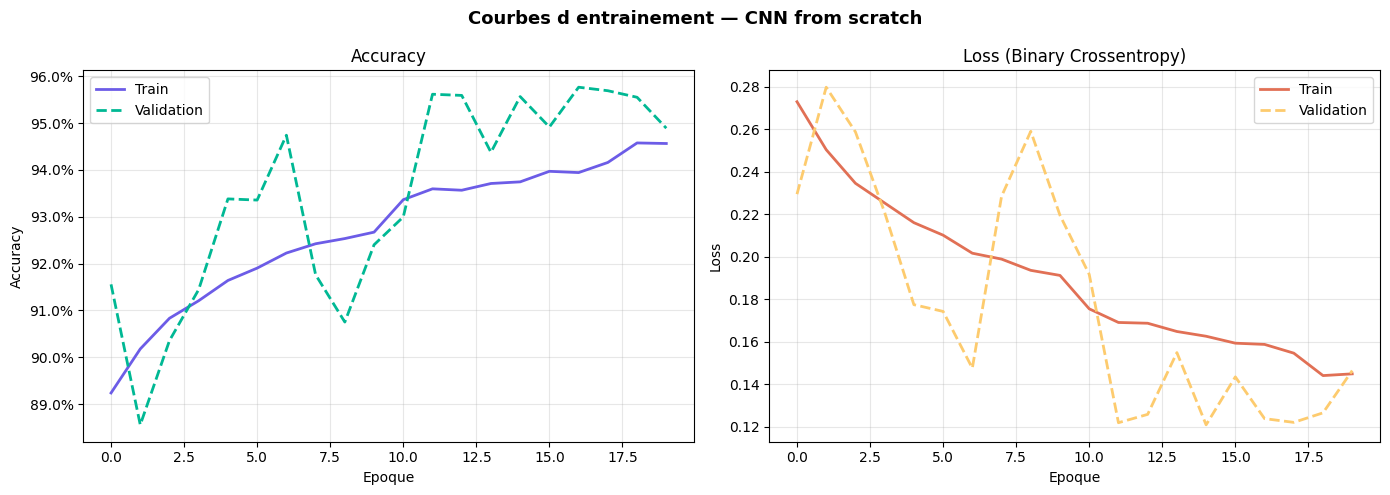

Sauvegarde : outputs/training_curves_cnn_from_scratch.png


In [17]:
# ── Courbes d'apprentissage ───────────────────────────────────────────────────
def plot_training_history(history, title='CNN'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Courbes d entrainement — {title}', fontsize=13, fontweight='bold')

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train',      color='#6C5CE7', lw=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation', color='#00B894', lw=2, linestyle='--')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoque')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

    # Loss
    axes[1].plot(history.history['loss'],     label='Train',      color='#E17055', lw=2)
    axes[1].plot(history.history['val_loss'], label='Validation', color='#FDCB6E', lw=2, linestyle='--')
    axes[1].set_title('Loss (Binary Crossentropy)')
    axes[1].set_xlabel('Epoque')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'outputs/training_curves_{title.lower().replace(" ", "_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Sauvegarde : outputs/training_curves_{title.lower().replace(" ", "_")}.png')

plot_training_history(history_cnn, 'CNN from scratch')

In [18]:
# ── Évaluation sur le jeu de test ─────────────────────────────────────────────
print('Evaluation sur le jeu de test...')
test_results = model_cnn.evaluate(test_generator, verbose=1)
metric_names = model_cnn.metrics_names

print('\nMetriques finales :')
for name, val in zip(metric_names, test_results):
    print(f'  {name:12s} : {val:.4f}')

Evaluation sur le jeu de test...
625/625 [==============================] - 178s 285ms/step - loss: 0.1209 - accuracy: 0.9556 - auc: 0.9916 - precision: 0.9722 - recall: 0.9381

Metriques finales :
  loss         : 0.1209
  accuracy     : 0.9556
  auc          : 0.9916
  precision    : 0.9722
  recall       : 0.9381


In [19]:
# ── Prédictions et métriques sklearn ─────────────────────────────────────────
# Réinitialiser le générateur (shuffle=False donc l'ordre est déterministe)
test_generator.reset()
y_proba = model_cnn.predict(test_generator, verbose=1)
y_pred  = (y_proba > 0.5).astype(int).flatten()
y_true  = test_generator.classes

# Classes : 0=FAKE, 1=REAL (selon class_indices du générateur train)
class_names = ['FAKE', 'REAL']

print('\nRapport de classification :')
print(classification_report(y_true, y_pred, target_names=class_names))

625/625 [==============================] - 149s 236ms/step

Rapport de classification :
              precision    recall  f1-score   support

        FAKE       0.94      0.97      0.96     10000
        REAL       0.97      0.94      0.95     10000

    accuracy                           0.96     20000
   macro avg       0.96      0.96      0.96     20000
weighted avg       0.96      0.96      0.96     20000



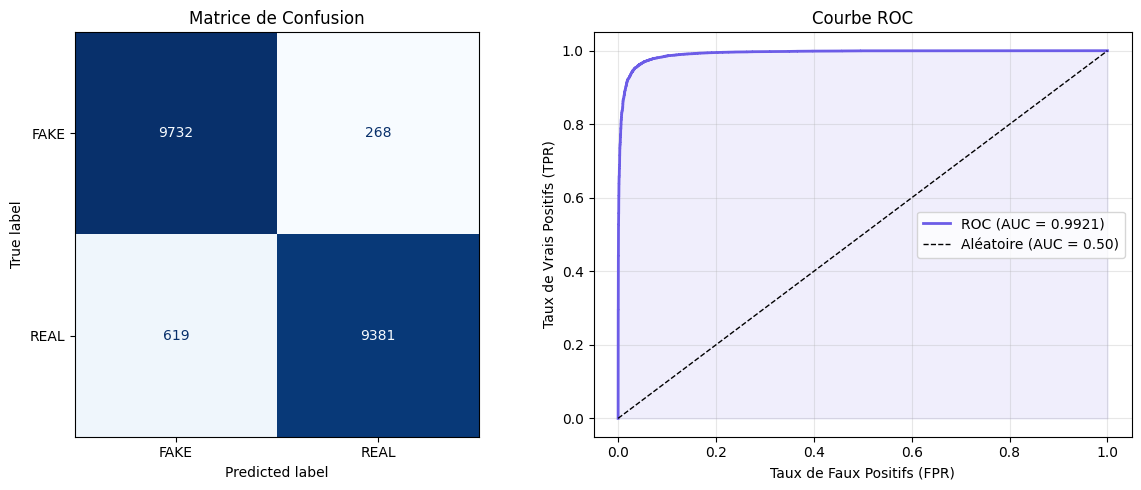

Sauvegarde : outputs/evaluation_cnn.png


In [20]:
# ── Matrice de confusion + Courbe ROC ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matrice de Confusion', fontsize=12)

# Courbe ROC
fpr, tpr, _ = roc_curve(y_true, y_proba.flatten())
roc_auc     = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#6C5CE7', lw=2,
             label=f'ROC (AUC = {roc_auc:.4f})')
axes[1].plot([0,1], [0,1], 'k--', lw=1, label='Aléatoire (AUC = 0.50)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#6C5CE7')
axes[1].set_xlabel('Taux de Faux Positifs (FPR)')
axes[1].set_ylabel('Taux de Vrais Positifs (TPR)')
axes[1].set_title('Courbe ROC', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/evaluation_cnn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegarde : outputs/evaluation_cnn.png')

---
## Étape 7 — Transfer Learning avec MobileNetV2 (Bonus)

### Pourquoi le Transfer Learning ?
Au lieu de partir de zéro, on utilise un modèle déjà entraîné sur **ImageNet**
(14 millions d'images, 1000 classes). MobileNetV2 a déjà appris à détecter
des textures, formes et structures complexes.

On **gèle** les couches de base et on ajoute notre propre tête de classification.

```
MobileNetV2 (poids ImageNet, gelé)
  → GlobalAveragePooling2D
  → Dense(128) + Dropout
  → Dense(1, sigmoid) ← seul cette partie est entraînée au début
```

Ensuite, on **dégèle** les 30 dernières couches pour un fine-tuning.


In [22]:
# ── Chargement de MobileNetV2 sans la tête de classification ─────────────────
base_model = MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,           # on retire la couche Dense finale d'ImageNet
    weights='imagenet'           # poids pré-entraînés sur ImageNet
)

# ── Geler toutes les couches de base ──────────────────────────────────────────
# Au début, on n'entraîne QUE notre nouvelle tête
base_model.trainable = False

print(f'MobileNetV2 chargee : {len(base_model.layers)} couches')
print(f'Couches gelees     : {sum(1 for l in base_model.layers if not l.trainable)}')

9406464/9406464 [==============================] - 1s 0us/step
MobileNetV2 chargee : 154 couches
Couches gelees     : 154


In [23]:
# ── Construction du modèle Transfer Learning ─────────────────────────────────
def build_transfer_model(base_model):
    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    
    # Prétraitement spécifique à MobileNetV2 (normalise [-1, 1])
    x = keras.applications.mobilenet_v2.preprocess_input(inputs)
    
    # Base pré-entraînée (gelée)
    x = base_model(x, training=False)
    
    # Notre tête de classification
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    return keras.Model(inputs, outputs, name='MobileNetV2_FineTuned')


model_tl = build_transfer_model(base_model)

model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

print(f'Parametres totaux       : {model_tl.count_params():,}')
print(f'Parametres entrainables : {sum([tf.size(w).numpy() for w in model_tl.trainable_weights]):,}')

Parametres totaux       : 2,422,081
Parametres entrainables : 164,097


In [25]:
# ── Phase 1 : entraîner uniquement la tête (10 epochs) ───────────────────────
print('Phase 1 : entrainement de la tete seulement...')

cbs_tl = [
     callbacks.ModelCheckpoint(
        'models/mobilenet_best.h5',   # ✅ CHANGER ICI
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0
    ),
    callbacks.EarlyStopping(monitor='val_loss', patience=4,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=2, min_lr=1e-7, verbose=1)
]

history_tl_phase1 = model_tl.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator,
    callbacks=cbs_tl,
    verbose=1
)

Phase 1 : entrainement de la tete seulement...
Epoch 1/10
3125/3125 [==============================] - 2199s 704ms/step - loss: 0.6506 - accuracy: 0.6177 - auc: 0.6608 - val_loss: 0.6052 - val_accuracy: 0.6778 - val_auc: 0.7458 - lr: 0.0010
Epoch 2/10
3125/3125 [==============================] - 1550s 496ms/step - loss: 0.6501 - accuracy: 0.6252 - auc: 0.6653 - val_loss: 0.6187 - val_accuracy: 0.6798 - val_auc: 0.7559 - lr: 0.0010
Epoch 3/10
3125/3125 [==============================] - 1284s 411ms/step - loss: 0.6468 - accuracy: 0.6304 - auc: 0.6745 - val_loss: 0.6024 - val_accuracy: 0.6957 - val_auc: 0.7668 - lr: 0.0010
Epoch 4/10
3125/3125 [==============================] - 1467s 469ms/step - loss: 0.6439 - accuracy: 0.6360 - auc: 0.6807 - val_loss: 0.6003 - val_accuracy: 0.6988 - val_auc: 0.7706 - lr: 0.0010
Epoch 5/10
3125/3125 [==============================] - 1666s 533ms/step - loss: 0.6404 - accuracy: 0.6406 - auc: 0.6867 - val_loss: 0.5946 - val_accuracy: 0.7035 - val_auc: 0.7

In [26]:
# ── Phase 2 : Fine-tuning — dégeler les 30 dernières couches ────────────────
print('\nPhase 2 : fine-tuning des 30 dernieres couches...')

# Dégeler partiellement
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

frozen   = sum(1 for l in base_model.layers if not l.trainable)
unfrozen = sum(1 for l in base_model.layers if l.trainable)
print(f'  Couches gelees   : {frozen}')
print(f'  Couches degelees : {unfrozen}')

# Recompiler avec un learning rate BEAUCOUP plus petit
# (pour ne pas détruire les poids pré-entraînés)
model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

history_tl_phase2 = model_tl.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator,
    callbacks=cbs_tl,
    verbose=1
)


Phase 2 : fine-tuning des 30 dernieres couches...
  Couches gelees   : 124
  Couches degelees : 30
Epoch 1/10
3125/3125 [==============================] - 3219s 1s/step - loss: 0.6810 - accuracy: 0.5645 - auc: 0.5931 - val_loss: 0.6758 - val_accuracy: 0.5788 - val_auc: 0.7272 - lr: 1.0000e-05
Epoch 2/10
3125/3125 [==============================] - 3416s 1s/step - loss: 0.6573 - accuracy: 0.6105 - auc: 0.6543 - val_loss: 0.6094 - val_accuracy: 0.6800 - val_auc: 0.7444 - lr: 1.0000e-05
Epoch 3/10
3125/3125 [==============================] - 4220s 1s/step - loss: 0.6412 - accuracy: 0.6331 - auc: 0.6836 - val_loss: 0.5938 - val_accuracy: 0.6933 - val_auc: 0.7607 - lr: 1.0000e-05
Epoch 4/10
3125/3125 [==============================] - 1901s 608ms/step - loss: 0.6321 - accuracy: 0.6439 - auc: 0.6984 - val_loss: 0.5820 - val_accuracy: 0.6968 - val_auc: 0.7717 - lr: 1.0000e-05
Epoch 5/10
3125/3125 [==============================] - 2218s 710ms/step - loss: 0.6221 - accuracy: 0.6548 - auc: 0.7

In [27]:
# ── Comparer les deux modèles ──────────────────────────────────────────────────
print('\nComparaison finale CNN scratch vs MobileNetV2 :')
print('=' * 50)

# CNN scratch
test_generator.reset()
res_cnn = model_cnn.evaluate(test_generator, verbose=0)
print(f'CNN from scratch  — Accuracy: {res_cnn[1]*100:.2f}%  AUC: {res_cnn[2]:.4f}')

# MobileNetV2
test_generator.reset()
res_tl  = model_tl.evaluate(test_generator, verbose=0)
print(f'MobileNetV2 TL    — Accuracy: {res_tl[1]*100:.2f}%  AUC: {res_tl[2]:.4f}')

best_model_label = 'MobileNetV2' if res_tl[1] > res_cnn[1] else 'CNN from scratch'
print(f'\nMeilleur modele : {best_model_label}')


Comparaison finale CNN scratch vs MobileNetV2 :
CNN from scratch  — Accuracy: 95.56%  AUC: 0.9916
MobileNetV2 TL    — Accuracy: 71.03%  AUC: 0.8045

Meilleur modele : CNN from scratch


---
## Étape 8 — Sauvegarde du modèle

On sauvegarde au format `.keras` (recommandé TF2) et on exporte aussi
un fichier `class_names.txt` pour que l'application web sache l'ordre des classes.


In [28]:
# ── Sauvegarder le meilleur des deux modèles ─────────────────────────────────
os.makedirs('models', exist_ok=True)

# Choisir le meilleur
if res_tl[1] > res_cnn[1]:
    final_model = model_tl
    final_name  = 'mobilenet_best.keras'
    print('Sauvegarde de MobileNetV2 comme modele final')
else:
    final_model = model_cnn
    final_name  = 'cnn_best.keras'
    print('Sauvegarde du CNN scratch comme modele final')

final_model.save(f'models/{final_name}')
final_model.save('models/image_classifier_final.keras')

# Sauvegarder les noms de classes (utile pour le web app)
import json
class_indices = train_generator.class_indices
# Inverser : {0: 'FAKE', 1: 'REAL'}
idx_to_class  = {v: k for k, v in class_indices.items()}
with open('models/class_names.json', 'w') as f:
    json.dump(idx_to_class, f)

print('\nFichiers sauvegardes :')
print('  models/image_classifier_final.keras')
print('  models/class_names.json')

Sauvegarde du CNN scratch comme modele final

Fichiers sauvegardes :
  models/image_classifier_final.keras
  models/class_names.json


---
## Étape 9 — Démo d'inférence sur une image

Fonction réutilisable par le web app pour prédire sur une image donnée.


In [29]:
# ── Rechargement du modèle depuis le disque ───────────────────────────────────
loaded_image_model = keras.models.load_model('models/image_classifier_final.keras')

with open('models/class_names.json') as f:
    idx_to_class = json.load(f)

print('Modele recharge avec succes')
print(f'Classes : {idx_to_class}')

Modele recharge avec succes
Classes : {'0': 'FAKE', '1': 'REAL'}


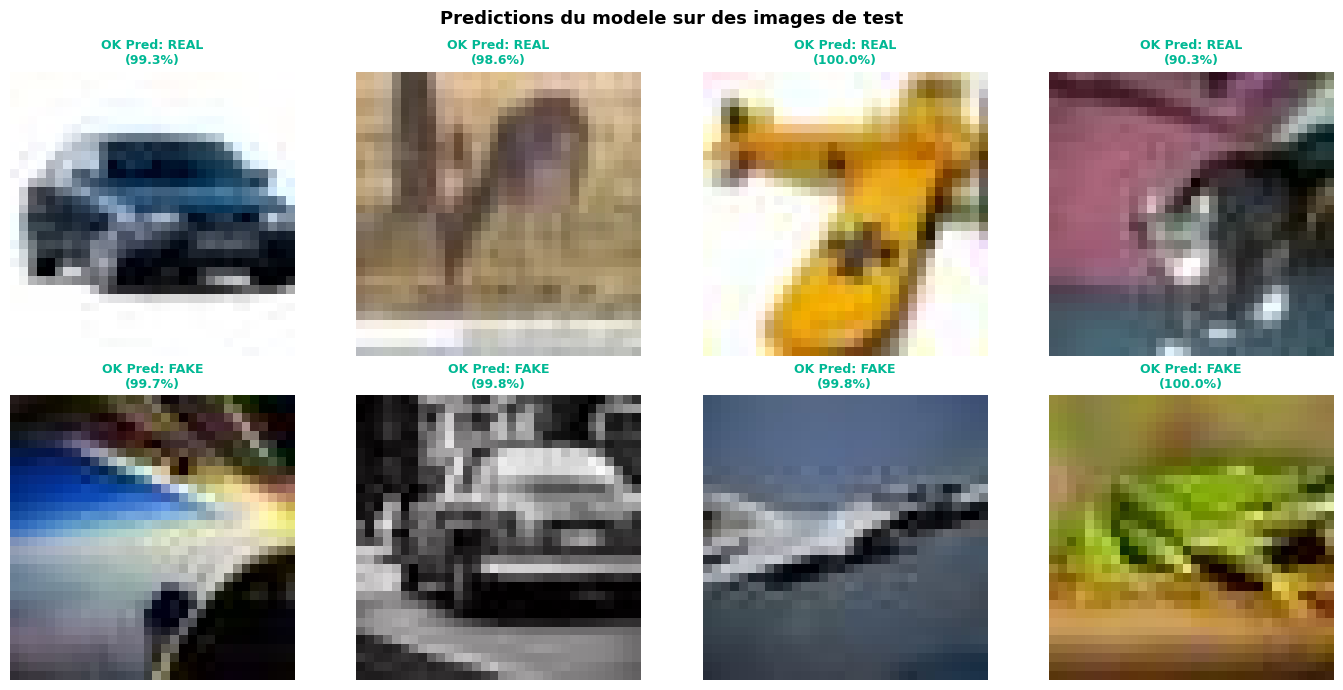

Sauvegarde : outputs/inference_demo.png


In [30]:
def predict_image(img_path, model=loaded_image_model, img_size=IMG_SIZE):
    """
    Prédit si une image est FAKE (générée par IA) ou REAL.
    
    Paramètres
    ----------
    img_path : str — chemin vers l'image
    model    : modèle Keras chargé
    img_size : tuple — taille cible (doit correspondre à l'entraînement)
    
    Retourne
    --------
    dict avec 'label', 'confidence', 'fake_proba', 'real_proba'
    """
    # 1. Charger et redimensionner
    img  = load_img(img_path, target_size=img_size)
    arr  = img_to_array(img)
    
    # 2. Normaliser [0,1]
    arr  = arr / 255.0
    
    # 3. Ajouter la dimension batch : (64,64,3) → (1,64,64,3)
    arr  = np.expand_dims(arr, axis=0)
    
    # 4. Prédire
    proba = model.predict(arr, verbose=0)[0][0]  # probabilité d'être REAL
    
    # 5. Interpréter
    label      = 'REAL' if proba >= 0.5 else 'FAKE'
    confidence = proba * 100 if proba >= 0.5 else (1 - proba) * 100
    
    return {
        'label'      : label,
        'confidence' : round(confidence, 1),
        'real_proba' : round(proba * 100, 1),
        'fake_proba' : round((1 - proba) * 100, 1)
    }


# ── Test sur des images du jeu de test ────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Predictions du modele sur des images de test', fontsize=13, fontweight='bold')

for row, cls in enumerate(['REAL', 'FAKE']):
    cls_path = os.path.join(TEST_DIR, cls)
    images   = os.listdir(cls_path)[:4]
    for col, img_name in enumerate(images):
        img_path = os.path.join(cls_path, img_name)
        result   = predict_image(img_path)
        
        img = load_img(img_path, target_size=IMG_SIZE)
        axes[row, col].imshow(img)
        
        # Couleur selon si la prédiction est correcte
        correct = (result['label'] == cls)
        color   = '#00B894' if correct else '#E17055'
        symbol  = 'OK' if correct else 'X'
        
        axes[row, col].set_title(
            f"{symbol} Pred: {result['label']}\n({result['confidence']:.1f}%)",
            fontsize=9, color=color, fontweight='bold'
        )
        axes[row, col].set_xlabel(f'Vrai : {cls}', fontsize=8)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('outputs/inference_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegarde : outputs/inference_demo.png')

In [31]:
# ── Résumé final ──────────────────────────────────────────────────────────────
print('=' * 55)
print('   RESUME — PARTIE 2 : AI IMAGE DETECTION')
print('=' * 55)
print(f'  Dataset    : CIFAKE (60 000 images REAL/FAKE)')
print(f'  Input size : {IMG_SIZE[0]}x{IMG_SIZE[1]} px, RGB')
print()
print(f'  CNN scratch   — Accuracy : {res_cnn[1]*100:.2f}%  AUC : {res_cnn[2]:.4f}')
print(f'  MobileNetV2   — Accuracy : {res_tl[1]*100:.2f}%  AUC : {res_tl[2]:.4f}')
print()
print('  Fichiers sauvegardes :')
print('    models/image_classifier_final.keras')
print('    models/class_names.json')
print('=' * 55)
print()
print('PARTIE 2 COMPLETE — Pret pour la Partie 3 (Web App) !')

   RESUME — PARTIE 2 : AI IMAGE DETECTION
  Dataset    : CIFAKE (60 000 images REAL/FAKE)
  Input size : 64x64 px, RGB

  CNN scratch   — Accuracy : 95.56%  AUC : 0.9916
  MobileNetV2   — Accuracy : 71.03%  AUC : 0.8045

  Fichiers sauvegardes :
    models/image_classifier_final.keras
    models/class_names.json

PARTIE 2 COMPLETE — Pret pour la Partie 3 (Web App) !


---
## Partie 2 terminée !

**Ce qu'on a accompli :**
- Dataset CIFAKE chargé et exploré (60 000 images IA vs réelles)
- Augmentation de données implémentée (rotation, zoom, flip, luminosité)
- CNN from scratch construit et entraîné (3 blocs convolutifs + BN + Dropout)
- Transfer Learning avec MobileNetV2 + fine-tuning des 30 dernières couches
- Évaluation : accuracy, AUC, matrice de confusion, courbe ROC
- Modèle final sauvegardé en `.keras`

---
**Prochaine étape : Partie 3 — Application Web Flask**
